In [181]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix,  ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

import nltk
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import wordnet
nltk.download("wordnet")
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\supra\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\supra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\supra\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\supra\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [182]:
df = pd.read_csv(r'C:\Users\supra\OneDrive\Documents\NLP\AirlineTweets.csv') #,encoding='ISO-8859-1'
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [183]:
df = df[['airline_sentiment','text']]

In [184]:
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


In [185]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.lower()
df['text']= df['text'].apply(clean_text)
df.head()

,airline_sentiment,text
0,neutral,virginamerica what dhepburn said
1,positive,virginamerica plus youve added commercials to ...
2,neutral,virginamerica i didnt today must mean i need t...
3,negative,virginamerica its really aggressive to blast o...
4,negative,virginamerica and its a really big bad thing a...


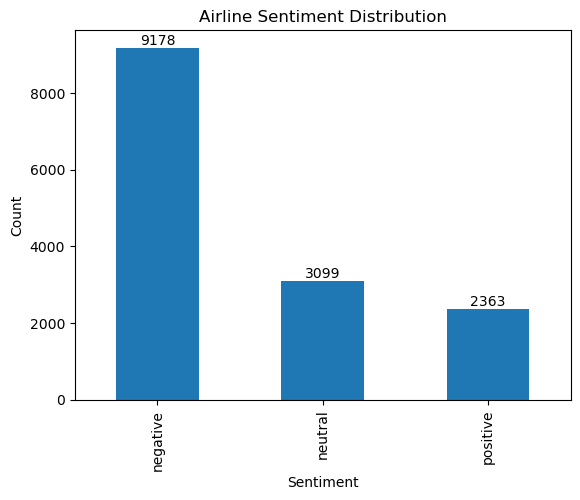

In [193]:
ax = df['airline_sentiment'].value_counts().plot(kind='bar')

ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.set_title('Airline Sentiment Distribution')

ax.bar_label(ax.containers[0])

plt.show()

# The histogram shows the dataset is imbalanced with very high negative sentiments

In [194]:
df['target']=df['airline_sentiment'].map({'positive':1,'negative':0,'neutral':2})

In [195]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(df['text'], df['target'], test_size=0.25, random_state=50)

In [196]:
def get_wordnet_pos(treebank_tag):
  if treebank_tag.startswith('J'):
    return wordnet.ADJ
  elif treebank_tag.startswith('V'):
    return wordnet.VERB
  elif treebank_tag.startswith('N'):
    return wordnet.NOUN
  elif treebank_tag.startswith('R'):
    return wordnet.ADV
  else:
    return wordnet.NOUN

def lemma_tokenizer(doc):
    wnl = WordNetLemmatizer()
    tokens = word_tokenize(doc)
    words_and_tags = nltk.pos_tag(tokens)
    return [wnl.lemmatize(word, pos=get_wordnet_pos(tag)) for word, tag in words_and_tags]

In [197]:
vectoriser = TfidfVectorizer(stop_words='english') #tokenizer=lemma_tokenizer
Xtrain = vectoriser.fit_transform(Xtrain)
Xtest = vectoriser.transform(Xtest)

In [198]:
from sklearn.svm import LinearSVC
model1 = LinearSVC(C=0.5)
model1.fit(Xtrain,Ytrain)
print("\n Train score:", model1.score(Xtrain,Ytrain))
print("\n Test score:", model1.score(Xtest, Ytest))
# the margain between train and test score is big indicating over-fitting


 Train score: 0.9277777777777778

 Test score: 0.7808743169398907


In [199]:
model = LogisticRegression(max_iter=1000)
model.fit(Xtrain,Ytrain)
print("\n Train score:", model.score(Xtrain,Ytrain))
print("\n Test score:", model.score(Xtest, Ytest))
# the margin between test and train score is reasonable


 Train score: 0.8717668488160292

 Test score: 0.7778688524590164


In [200]:
Ypred = model.predict(Xtest)


 Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.93      0.86      2312
           1       0.82      0.59      0.68       586
           2       0.64      0.47      0.54       762

    accuracy                           0.78      3660
   macro avg       0.75      0.66      0.70      3660
weighted avg       0.77      0.78      0.77      3660



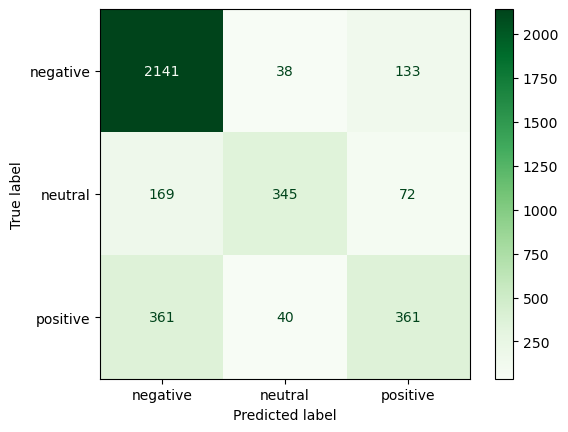

In [201]:
print("\n Classification Report:\n", classification_report(Ytest, Ypred))
ConfusionMatrixDisplay.from_predictions(
    Ytest,
    Ypred,
    display_labels=["negative","neutral","positive"],
    cmap="Greens")
plt.show()

In [204]:
feature_names = vectoriser.get_feature_names_out()

# Top positive words:
coef = model.coef_[1]
top_positive = pd.Series(coef, index=feature_names).sort_values(ascending=False)
top_positive.head(20)

thanks         5.059133
thank          4.771587
great          3.919080
love           3.450702
awesome        3.313166
amazing        3.075719
best           2.770145
appreciate     2.379335
kudos          2.291187
excellent      2.223056
good           2.211424
thx            2.173391
wonderful      2.023123
excited        2.021734
rock           1.987025
happy          1.672402
appreciated    1.623331
worries        1.497238
sweet          1.441510
helpful        1.404346
dtype: float64